# Comparison of the 500k baselines: batch size 64 vs 256

This notebook compares the two trained `SimpleCNN_Baseline` models using the same 500k dataset:

- **M00_bs64**: original baseline trained with the conventional loader.
- **M00_bs256_batchslices**: faster training using `HDF5BatchIterableDataset`.

The comparison is made on the common **validation, calibration and test samples**. It includes:

1. file and split integrity checks;
2. standardized and physical-space metrics;
3. absolute-error quantiles;
4. regression-to-the-mean diagnostics for all three labels;
5. bias and error as a function of the true parameter;
6. direct deltas between the two models;
7. training-history comparison.

The final decision should be based primarily on the **test split**. Validation is useful for model development, while calibration should remain reserved for conformal calibration.


In [1]:
from pathlib import Path
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run the notebook either from the repository root or from its notebooks/ directory.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name != "cbc_pe" and (PROJECT_ROOT / "cbc_pe").exists():
    PROJECT_ROOT = PROJECT_ROOT / "cbc_pe"

# Local synchronized artifacts. raw/ and processed/ are intentionally absent locally.
DATA_ROOT = Path("/data/vserrano/cbc_pe_data")
RESULTS_DIR = DATA_ROOT / "results"
CHECKPOINTS_DIR = DATA_ROOT / "models" / "checkpoints"

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "outputs" / "comparison_500k_bs64_vs_bs256"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_NAMES_DEFAULT = ["chirp_mass", "total_mass", "chi_eff"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RESULTS_DIR exists:", RESULTS_DIR.exists())
print("CHECKPOINTS_DIR exists:", CHECKPOINTS_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe
DATA_ROOT: /data/vserrano/cbc_pe_data
RESULTS_DIR exists: True
CHECKPOINTS_DIR exists: True
OUTPUT_DIR: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/notebooks/outputs/comparison_500k_bs64_vs_bs256


## 1. Register the two runs

In [3]:
DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"

RUNS = {
    "M00_bs64": {
        "prediction": RESULTS_DIR / DATASET_ID / (
            "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_"
            "SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123_"
            "train_val_cal_test_predictions_embeddings.npz"
        ),
        "history": RESULTS_DIR / DATASET_ID / (
            "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_"
            "SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123_history.npz"
        ),
        "checkpoint": CHECKPOINTS_DIR / DATASET_ID / (
            "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_"
            "SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123_checkpoint.pt"
        ),
    },
    "M00_bs256_batchslices": {
        "prediction": RESULTS_DIR / DATASET_ID / (
            "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_"
            "SimpleCNN_Baseline_batchslices_bs256_MSELoss_seed123_"
            "val_cal_test_predictions_embeddings.npz"
        ),
        "history": RESULTS_DIR / DATASET_ID / (
            "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_"
            "SimpleCNN_Baseline_batchslices_bs256_MSELoss_seed123_history.npz"
        ),
        "checkpoint": CHECKPOINTS_DIR / DATASET_ID / (
            "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_"
            "SimpleCNN_Baseline_batchslices_bs256_MSELoss_seed123_checkpoint.pt"
        ),
    },
}

file_rows = []
for run_id, paths in RUNS.items():
    row = {"run_id": run_id}
    for kind, path in paths.items():
        row[f"{kind}_exists"] = path.exists()
        row[f"{kind}_path"] = str(path)
        row[f"{kind}_size_MB"] = path.stat().st_size / 1024**2 if path.exists() else np.nan
    file_rows.append(row)

files_df = pd.DataFrame(file_rows)
files_df


,run_id,prediction_exists,prediction_path,prediction_size_MB,history_exists,history_path,history_size_MB,checkpoint_exists,checkpoint_path,checkpoint_size_MB
0,M00_bs64,True,/data/vserrano/cbc_pe_data/results/bbh_process...,125.613692,True,/data/vserrano/cbc_pe_data/results/bbh_process...,0.001893,True,/data/vserrano/cbc_pe_data/models/checkpoints/...,2.153039
1,M00_bs256_batchslices,True,/data/vserrano/cbc_pe_data/results/bbh_process...,24.903821,True,/data/vserrano/cbc_pe_data/results/bbh_process...,0.005823,True,/data/vserrano/cbc_pe_data/models/checkpoints/...,2.158959


In [4]:
missing_predictions = [
    run_id for run_id, paths in RUNS.items()
    if not paths["prediction"].exists()
]
assert not missing_predictions, f"Missing prediction files for: {missing_predictions}"


## 2. Load files and verify compatibility

In [5]:
def load_prediction_file(path):
    with np.load(path, allow_pickle=True) as data:
        return {key: data[key] for key in data.files}


run_data = {
    run_id: load_prediction_file(paths["prediction"])
    for run_id, paths in RUNS.items()
}

for run_id, data in run_data.items():
    available_splits = [
        split for split in ("train", "val", "cal", "test")
        if f"pred_{split}" in data and f"y_{split}" in data
    ]
    print("\n", run_id)
    print("  splits:", available_splits)
    print("  labels:", [str(x) for x in data.get("label_names", LABEL_NAMES_DEFAULT).tolist()])
    for split in available_splits:
        print(
            f"  {split:5s}",
            "pred", data[f"pred_{split}"].shape,
            "emb", data[f"emb_{split}"].shape,
            "y", data[f"y_{split}"].shape,
            "idx", data[f"idx_{split}"].shape,
        )



 M00_bs64
  splits: ['train', 'val', 'cal', 'test']
  labels: ['chirp_mass', 'total_mass', 'chi_eff']
  train pred (400000, 3) emb (400000, 64) y (400000, 3) idx (400000,)
  val   pred (40000, 3) emb (40000, 64) y (40000, 3) idx (40000,)
  cal   pred (30000, 3) emb (30000, 64) y (30000, 3) idx (30000,)
  test  pred (30000, 3) emb (30000, 64) y (30000, 3) idx (30000,)

 M00_bs256_batchslices
  splits: ['val', 'cal', 'test']
  labels: ['chirp_mass', 'total_mass', 'chi_eff']
  val   pred (40000, 3) emb (40000, 64) y (40000, 3) idx (40000,)
  cal   pred (30000, 3) emb (30000, 64) y (30000, 3) idx (30000,)
  test  pred (30000, 3) emb (30000, 64) y (30000, 3) idx (30000,)


In [6]:
reference_id = "M00_bs64"
reference = run_data[reference_id]

label_names = [
    str(x) for x in reference.get("label_names", np.array(LABEL_NAMES_DEFAULT)).tolist()
]
y_mean = np.asarray(reference["y_mean"], dtype=np.float64)
y_std = np.asarray(reference["y_std"], dtype=np.float64)

for run_id, data in run_data.items():
    np.testing.assert_allclose(data["y_mean"], y_mean, rtol=0, atol=1e-7)
    np.testing.assert_allclose(data["y_std"], y_std, rtol=0, atol=1e-7)

print("Compatible label statistics.")
print("label_names:", label_names)
print("y_mean:", y_mean)
print("y_std:", y_std)


Compatible label statistics.
label_names: ['chirp_mass', 'total_mass', 'chi_eff']
y_mean: [3.74526215e+01 9.49739685e+01 1.02269521e-03]
y_std: [16.48472214 34.65016556  0.44085518]


### Align samples by physical HDF5 index

The two prediction files may store each split in a different row order. The comparison therefore aligns them using `idx_val`, `idx_cal` and `idx_test` rather than assuming that row `i` refers to the same event.


In [7]:
def aligned_split(run_data, split, reference_run="M00_bs64"):
    common = None

    for data in run_data.values():
        idx = np.asarray(data[f"idx_{split}"], dtype=np.int64)
        common = idx if common is None else np.intersect1d(common, idx)

    common = np.asarray(common, dtype=np.int64)
    aligned = {}

    for run_id, data in run_data.items():
        idx = np.asarray(data[f"idx_{split}"], dtype=np.int64)
        order = np.argsort(idx)
        idx_sorted = idx[order]

        positions = np.searchsorted(idx_sorted, common)
        if not np.array_equal(idx_sorted[positions], common):
            raise ValueError(f"Could not align all {split} indices for {run_id}")

        aligned[run_id] = {
            "idx": common,
            "pred": np.asarray(data[f"pred_{split}"])[order][positions],
            "y": np.asarray(data[f"y_{split}"])[order][positions],
            "emb": np.asarray(data[f"emb_{split}"])[order][positions],
        }

    y_ref = aligned[reference_run]["y"]
    for run_id, arrays in aligned.items():
        np.testing.assert_allclose(
            arrays["y"], y_ref,
            rtol=1e-5,
            atol=1e-5,
            err_msg=f"Target mismatch after aligning {split}: {run_id}",
        )

    return aligned


ALIGNED = {
    split: aligned_split(run_data, split)
    for split in ("val", "cal", "test")
}

for split, models in ALIGNED.items():
    print(split, "common samples:", len(next(iter(models.values()))["idx"]))


val common samples: 40000
cal common samples: 30000
test common samples: 30000


## 3. Metric helpers

In [8]:
def regression_metrics(y_true, y_pred):
    # Sign convention used throughout this notebook:
    # residual = prediction - truth
    residual = y_pred - y_true
    abs_error = np.abs(residual)

    mse = np.mean(residual**2, axis=0)
    rmse = np.sqrt(mse)
    mae = np.mean(abs_error, axis=0)
    bias = np.mean(residual, axis=0)
    median_abs_error = np.median(abs_error, axis=0)
    residual_std = np.std(residual, axis=0)

    ss_res = np.sum(residual**2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0))**2, axis=0)
    r2 = 1.0 - ss_res / ss_tot

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "median_abs_error": median_abs_error,
        "residual_std": residual_std,
        "r2": r2,
        "global_mse": float(np.mean(residual**2)),
        "global_rmse": float(np.sqrt(np.mean(residual**2))),
        "global_mae": float(np.mean(abs_error)),
    }


def to_physical(y_standardized):
    return y_standardized * y_std + y_mean


def slope_diagnostics(y_true, y_pred):
    rows = []
    for j, label in enumerate(label_names):
        slope, intercept = np.polyfit(y_true[:, j], y_pred[:, j], deg=1)
        correlation = np.corrcoef(y_true[:, j], y_pred[:, j])[0, 1]
        rows.append({
            "label": label,
            "slope": float(slope),
            "intercept": float(intercept),
            "correlation": float(correlation),
            "true_min": float(y_true[:, j].min()),
            "true_max": float(y_true[:, j].max()),
            "pred_min": float(y_pred[:, j].min()),
            "pred_max": float(y_pred[:, j].max()),
            "range_ratio_pred_over_true": float(
                np.ptp(y_pred[:, j]) / np.ptp(y_true[:, j])
            ),
        })
    return rows


## 4. Compute metrics on val/cal/test

In [9]:
metric_rows = []
quantile_rows = []
slope_rows = []

for split, models in ALIGNED.items():
    for run_id, arrays in models.items():
        for space in ("standardized", "physical"):
            if space == "standardized":
                y_true = arrays["y"]
                y_pred = arrays["pred"]
            else:
                y_true = to_physical(arrays["y"])
                y_pred = to_physical(arrays["pred"])

            metrics = regression_metrics(y_true, y_pred)

            metric_rows.append({
                "run_id": run_id,
                "split": split,
                "space": space,
                "label": "global",
                "MSE": metrics["global_mse"],
                "RMSE": metrics["global_rmse"],
                "MAE": metrics["global_mae"],
                "Bias_pred_minus_true": np.nan,
                "Median_abs_error": np.nan,
                "Residual_std": np.nan,
                "R2": np.nan,
                "n_samples": len(y_true),
            })

            abs_error = np.abs(y_pred - y_true)

            for j, label in enumerate(label_names):
                metric_rows.append({
                    "run_id": run_id,
                    "split": split,
                    "space": space,
                    "label": label,
                    "MSE": metrics["mse"][j],
                    "RMSE": metrics["rmse"][j],
                    "MAE": metrics["mae"][j],
                    "Bias_pred_minus_true": metrics["bias"][j],
                    "Median_abs_error": metrics["median_abs_error"][j],
                    "Residual_std": metrics["residual_std"][j],
                    "R2": metrics["r2"][j],
                    "n_samples": len(y_true),
                })

                q50, q68, q90, q95, q99 = np.quantile(
                    abs_error[:, j], [0.50, 0.68, 0.90, 0.95, 0.99]
                )
                quantile_rows.append({
                    "run_id": run_id,
                    "split": split,
                    "space": space,
                    "label": label,
                    "q50": q50,
                    "q68": q68,
                    "q90": q90,
                    "q95": q95,
                    "q99": q99,
                })

            if space == "physical":
                for row in slope_diagnostics(y_true, y_pred):
                    row.update({"run_id": run_id, "split": split})
                    slope_rows.append(row)

metrics_df = pd.DataFrame(metric_rows)
quantiles_df = pd.DataFrame(quantile_rows)
slopes_df = pd.DataFrame(slope_rows)


### Main test results: standardized space

In [10]:
test_std = metrics_df.query(
    "split == 'test' and space == 'standardized'"
).copy()

test_std.sort_values(["label", "MSE"])


,run_id,split,space,label,MSE,RMSE,MAE,Bias_pred_minus_true,Median_abs_error,Residual_std,R2,n_samples
35,M00_bs64,test,standardized,chi_eff,0.217231,0.466081,0.351326,-0.012243,0.271697,0.465921,0.782242,30000
43,M00_bs256_batchslices,test,standardized,chi_eff,0.220129,0.469179,0.351007,-0.007952,0.270502,0.469112,0.779337,30000
41,M00_bs256_batchslices,test,standardized,chirp_mass,0.108980,0.330121,0.234635,0.003093,0.165901,0.330106,0.891645,30000
33,M00_bs64,test,standardized,chirp_mass,0.110171,0.331920,0.236852,-0.008680,0.167923,0.331807,0.890461,30000
32,M00_bs64,test,standardized,global,0.138343,0.371945,0.268687,NaN,NaN,NaN,NaN,30000
40,M00_bs256_batchslices,test,standardized,global,0.139021,0.372855,0.267648,NaN,NaN,NaN,NaN,30000
34,M00_bs64,test,standardized,total_mass,0.087625,0.296015,0.217886,-0.025521,0.164329,0.294914,0.912520,30000
42,M00_bs256_batchslices,test,standardized,total_mass,0.087953,0.296568,0.217300,-0.014598,0.162254,0.296209,0.912193,30000


### Main test results: physical space

In [11]:
test_phys = metrics_df.query(
    "split == 'test' and space == 'physical' and label != 'global'"
).copy()

test_phys.sort_values(["label", "RMSE"])


,run_id,split,space,label,MSE,RMSE,MAE,Bias_pred_minus_true,Median_abs_error,Residual_std,R2,n_samples
39,M00_bs64,test,physical,chi_eff,0.042220,0.205475,0.154883,-0.005397,0.119779,0.205404,0.782241,30000
47,M00_bs256_batchslices,test,physical,chi_eff,0.042783,0.206840,0.154743,-0.003506,0.119252,0.206811,0.779337,30000
45,M00_bs256_batchslices,test,physical,chirp_mass,29.614973,5.441964,3.867905,0.050990,2.734825,5.441725,0.891645,30000
37,M00_bs64,test,physical,chirp_mass,29.938596,5.471617,3.904429,-0.143082,2.768165,5.469746,0.890461,30000
38,M00_bs64,test,physical,total_mass,105.205945,10.256995,7.549754,-0.884308,5.694032,10.218803,0.912520,30000
46,M00_bs256_batchslices,test,physical,total_mass,105.599296,10.276152,7.529537,-0.505809,5.622138,10.263696,0.912193,30000


## 5. Direct deltas: bs256 relative to bs64

In [12]:
def paired_delta_table(df, value_columns, index_columns):
    wide = df.pivot(index=index_columns, columns="run_id", values=value_columns)

    rows = []
    for index_values, row in wide.iterrows():
        if not isinstance(index_values, tuple):
            index_values = (index_values,)

        out = dict(zip(index_columns, index_values))
        for metric in value_columns:
            old = row[(metric, "M00_bs64")]
            new = row[(metric, "M00_bs256_batchslices")]
            out[f"{metric}_bs64"] = old
            out[f"{metric}_bs256"] = new
            out[f"{metric}_delta"] = new - old
            out[f"{metric}_relative_change_pct"] = 100.0 * (new - old) / old
        rows.append(out)

    return pd.DataFrame(rows)


test_delta_df = paired_delta_table(
    metrics_df.query(
        "split == 'test' and space == 'standardized'"
    ),
    value_columns=["MSE", "MAE", "R2"],
    index_columns=["label"],
)

test_delta_df


,label,MSE_bs64,MSE_bs256,MSE_delta,MSE_relative_change_pct,MAE_bs64,MAE_bs256,MAE_delta,MAE_relative_change_pct,R2_bs64,R2_bs256,R2_delta,R2_relative_change_pct
0,chi_eff,0.217231,0.220129,0.002898,1.333948,0.351326,0.351007,-0.000319,-0.090868,0.782242,0.779337,-0.002905,-0.371339
1,chirp_mass,0.110171,0.108980,-0.001191,-1.081125,0.236852,0.234635,-0.002216,-0.935737,0.890461,0.891645,0.001184,0.132997
2,global,0.138343,0.139021,0.000678,0.490056,0.268687,0.267648,-0.001039,-0.386706,NaN,NaN,NaN,NaN
3,total_mass,0.087625,0.087953,0.000328,0.374124,0.217886,0.217300,-0.000586,-0.268853,0.912520,0.912193,-0.000327,-0.035867


Interpretation:

- Negative `MSE_relative_change_pct` or `MAE_relative_change_pct` means bs256 improved.
- Positive `R2_delta` means bs256 improved.
- Small changes should not be overinterpreted without checking whether the pattern is consistent across val, cal and test.


In [13]:
global_stability_df = metrics_df.query(
    "space == 'standardized' and label == 'global'"
).pivot(index="split", columns="run_id", values="MSE")

global_stability_df["delta_bs256_minus_bs64"] = (
    global_stability_df["M00_bs256_batchslices"]
    - global_stability_df["M00_bs64"]
)
global_stability_df["relative_change_pct"] = (
    100.0
    * global_stability_df["delta_bs256_minus_bs64"]
    / global_stability_df["M00_bs64"]
)

global_stability_df


run_id,M00_bs256_batchslices,M00_bs64,delta_bs256_minus_bs64,relative_change_pct
split,,,,
cal,0.141373,0.138436,0.002937,2.121467
test,0.139021,0.138343,0.000678,0.490056
val,0.137655,0.137901,-0.000246,-0.178035


## 6. Regression-to-the-mean diagnostics

In [14]:
slopes_df.query("split == 'test'").sort_values(["label", "run_id"])


,label,slope,intercept,correlation,true_min,true_max,pred_min,pred_max,range_ratio_pred_over_true,run_id,split
17,chi_eff,0.781787,-0.002500,0.882841,-0.995358,0.993714,-0.916054,0.996476,0.961519,M00_bs256_batchslices,test
14,chi_eff,0.772806,-0.004351,0.884597,-0.995358,0.993714,-0.875727,0.982366,0.934151,M00_bs64,test
15,chirp_mass,0.883630,4.416815,0.944314,4.573941,77.771958,5.389991,76.109637,0.966142,M00_bs256_batchslices,test
12,chirp_mass,0.869197,4.764231,0.943967,4.573941,77.771958,5.805065,75.795075,0.956174,M00_bs64,test
16,total_mass,0.915028,7.578131,0.955203,10.519634,178.673126,8.554053,172.372896,0.974222,M00_bs256_batchslices,test
13,total_mass,0.903660,8.281099,0.955652,10.519634,178.673126,10.726826,173.343881,0.967075,M00_bs64,test


For the fit

$$
\widehat{y} = a\,y + b,
$$

a slope `a < 1` indicates contraction toward the centre of the target distribution. The closer the slope and range ratio are to 1, the less severe the contraction.


In [15]:
test_slope_delta = slopes_df.query("split == 'test'").pivot(
    index="label",
    columns="run_id",
    values=["slope", "range_ratio_pred_over_true", "correlation"],
)

test_slope_delta


slope           range_ratio_pred_over_true  \
run_id     M00_bs256_batchslices  M00_bs64      M00_bs256_batchslices   
label                                                                   
chi_eff                 0.781787  0.772806                   0.961519   
chirp_mass              0.883630  0.869197                   0.966142   
total_mass              0.915028  0.903660                   0.974222   

                               correlation            
run_id      M00_bs64 M00_bs256_batchslices  M00_bs64  
label                                                 
chi_eff     0.934151              0.882841  0.884597  
chirp_mass  0.956174              0.944314  0.943967  
total_mass  0.967075              0.955203  0.955652

### Predicted versus true values

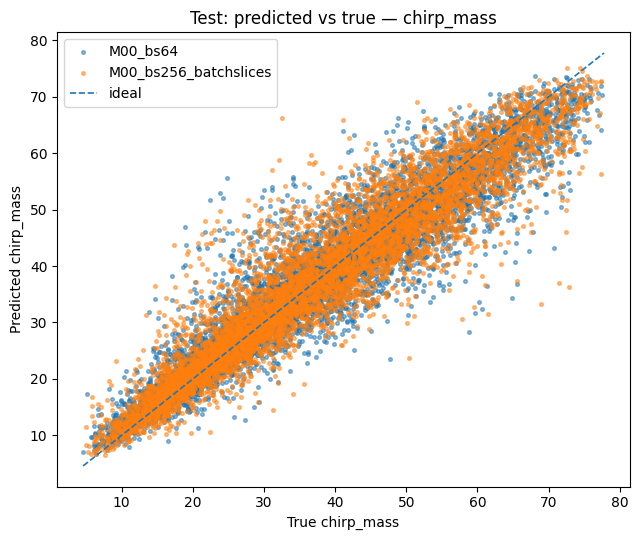

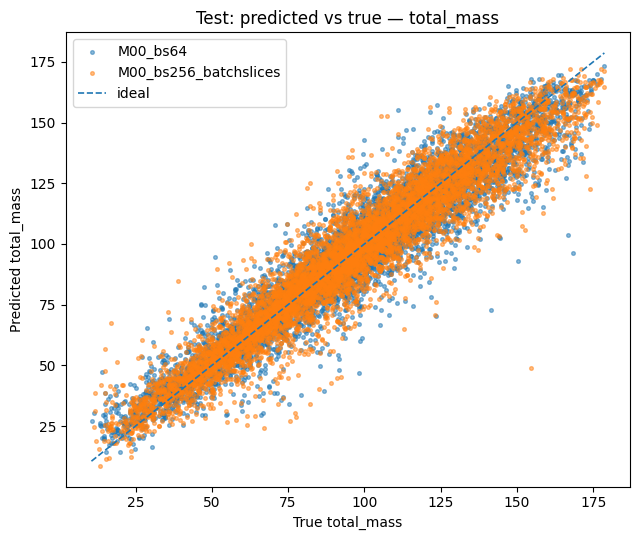

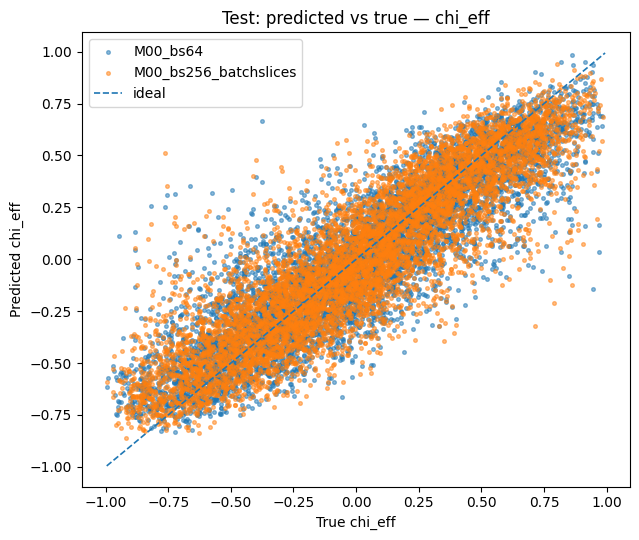

In [21]:
rng = np.random.default_rng(123)
split = "test"
max_points = 7000

for j, label in enumerate(label_names):
    plt.figure(figsize=(6.5, 5.5))

    for run_id, arrays in ALIGNED[split].items():
        y_true = to_physical(arrays["y"])[:, j]
        y_pred = to_physical(arrays["pred"])[:, j]

        n_plot = min(max_points, len(y_true))
        positions = rng.choice(len(y_true), size=n_plot, replace=False)

        plt.scatter(
            y_true[positions],
            y_pred[positions],
            s=7,
            alpha=0.5,
            label=run_id,
        )

    all_true = np.concatenate([
        to_physical(arrays["y"])[:, j]
        for arrays in ALIGNED[split].values()
    ])
    lo, hi = all_true.min(), all_true.max()
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.2, label="ideal")

    plt.xlabel(f"True {label}")
    plt.ylabel(f"Predicted {label}")
    plt.title(f"Test: predicted vs true — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 7. Bias and error across the true-parameter range

In [18]:
def binned_true_diagnostics(y_true, y_pred, n_bins=8):
    rows = []

    for j, label in enumerate(label_names):
        # Shared quantile edges ensure enough samples in every bin.
        edges = np.quantile(y_true[:, j], np.linspace(0, 1, n_bins + 1))
        edges = np.unique(edges)

        bin_idx = np.digitize(y_true[:, j], edges[1:-1], right=False)

        for b in range(len(edges) - 1):
            mask = bin_idx == b
            if not np.any(mask):
                continue

            residual = y_pred[mask, j] - y_true[mask, j]
            abs_error = np.abs(residual)

            rows.append({
                "label": label,
                "bin": b,
                "low": edges[b],
                "high": edges[b + 1],
                "true_mean": y_true[mask, j].mean(),
                "pred_mean": y_pred[mask, j].mean(),
                "n_samples": int(mask.sum()),
                "bias_pred_minus_true": residual.mean(),
                "MAE": abs_error.mean(),
                "RMSE": np.sqrt(np.mean(residual**2)),
                "q90_abs_error": np.quantile(abs_error, 0.90),
            })

    return pd.DataFrame(rows)


binned_rows = []
for run_id, arrays in ALIGNED["test"].items():
    y_true_phys = to_physical(arrays["y"])
    y_pred_phys = to_physical(arrays["pred"])

    diag = binned_true_diagnostics(y_true_phys, y_pred_phys, n_bins=8)
    diag.insert(0, "run_id", run_id)
    binned_rows.append(diag)

binned_df = pd.concat(binned_rows, ignore_index=True)
binned_df.head()


,run_id,label,bin,low,high,true_mean,pred_mean,n_samples,bias_pred_minus_true,MAE,RMSE,q90_abs_error
0,M00_bs64,chirp_mass,0,4.573941,17.626058,13.662415,15.773459,3750,2.111044,2.589925,3.760492,5.608548
1,M00_bs64,chirp_mass,1,17.626058,23.852234,20.745600,22.609477,3750,1.863877,2.934232,4.604147,6.486322
2,M00_bs64,chirp_mass,2,23.852234,29.990415,26.895585,28.511786,3750,1.616201,3.329318,5.010932,7.643251
3,M00_bs64,chirp_mass,3,29.990415,36.254585,33.066473,34.262341,3750,1.195868,3.897612,5.478258,8.549656
4,M00_bs64,chirp_mass,4,36.254585,42.930930,39.582775,39.657358,3750,0.074584,3.975255,5.284213,8.655298


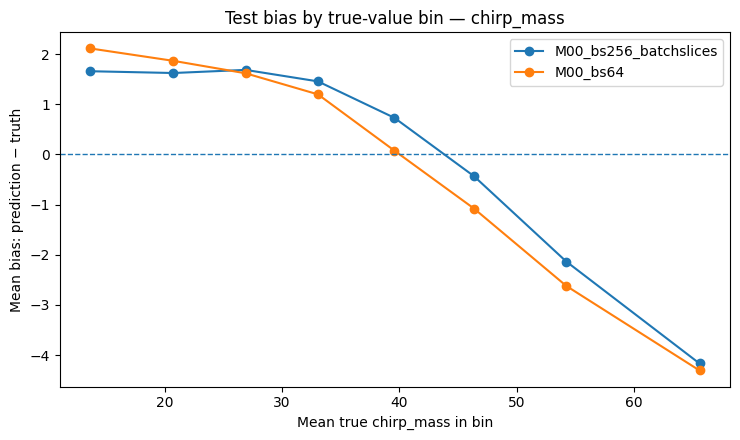

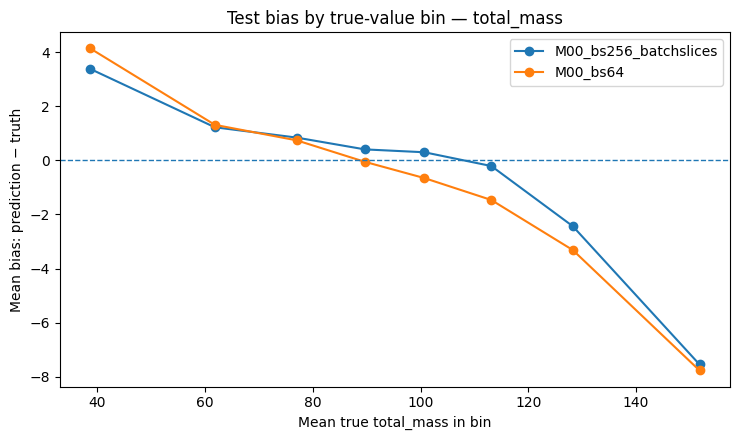

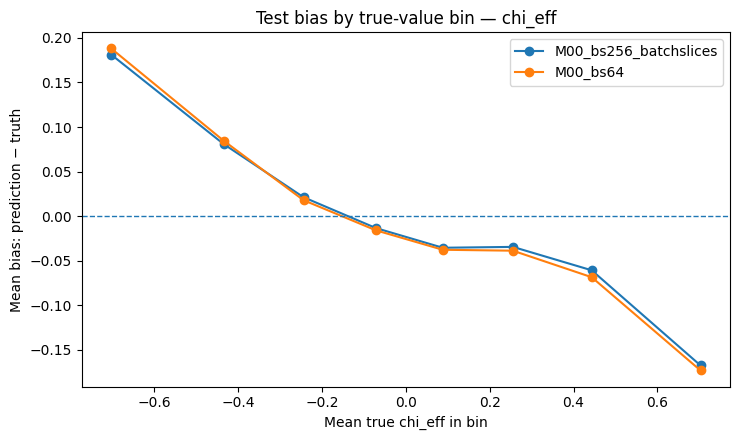

In [19]:
for label in label_names:
    subset = binned_df.query("label == @label")

    plt.figure(figsize=(7.5, 4.5))
    for run_id, group in subset.groupby("run_id"):
        plt.plot(
            group["true_mean"],
            group["bias_pred_minus_true"],
            marker="o",
            label=run_id,
        )

    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel(f"Mean true {label} in bin")
    plt.ylabel("Mean bias: prediction − truth")
    plt.title(f"Test bias by true-value bin — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()


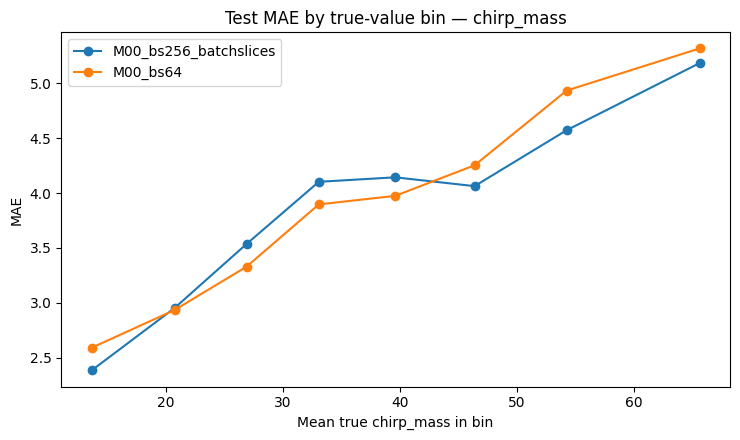

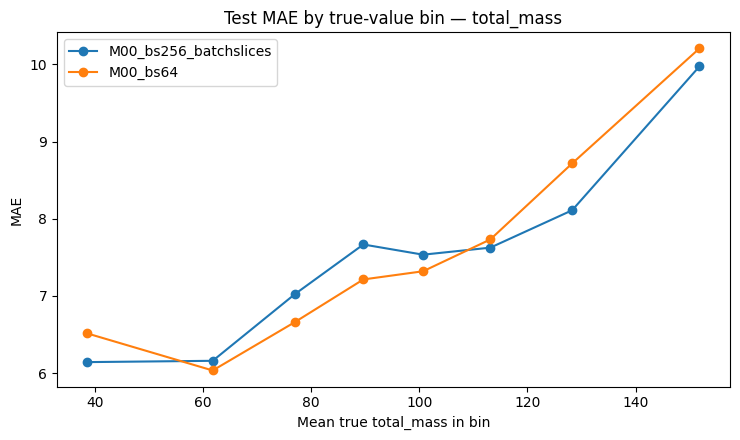

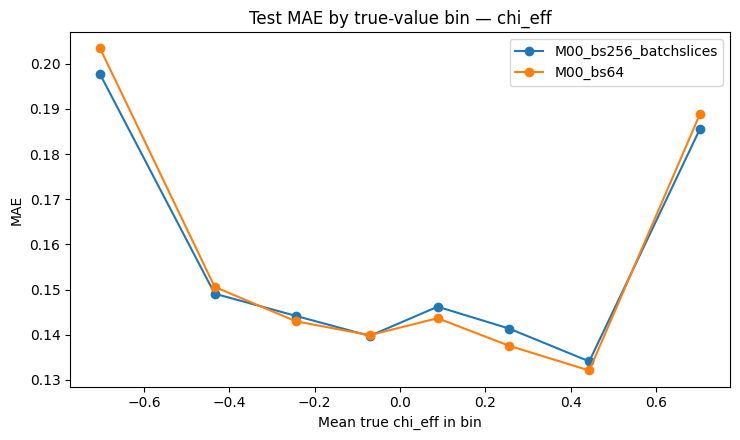

In [20]:
for label in label_names:
    subset = binned_df.query("label == @label")

    plt.figure(figsize=(7.5, 4.5))
    for run_id, group in subset.groupby("run_id"):
        plt.plot(
            group["true_mean"],
            group["MAE"],
            marker="o",
            label=run_id,
        )

    plt.xlabel(f"Mean true {label} in bin")
    plt.ylabel("MAE")
    plt.title(f"Test MAE by true-value bin — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 8. Training-history comparison

In [22]:
def load_history(path):
    with np.load(path, allow_pickle=True) as data:
        if "train_loss" in data.files and "val_loss" in data.files:
            train_loss = np.asarray(data["train_loss"], dtype=float)
            val_loss = np.asarray(data["val_loss"], dtype=float)
        elif "history" in data.files:
            obj = data["history"].tolist()
            if not isinstance(obj, dict):
                raise ValueError(f"Unsupported history format: {path}")
            train_loss = np.asarray(obj["train_loss"], dtype=float)
            val_loss = np.asarray(obj["val_loss"], dtype=float)
        else:
            raise KeyError(f"No train_loss/val_loss in {path}")

    return pd.DataFrame({
        "epoch": np.arange(1, len(train_loss) + 1),
        "train_loss": train_loss,
        "val_loss": val_loss,
    })


history_frames = {}
history_rows = []

for run_id, paths in RUNS.items():
    if not paths["history"].exists():
        print("Missing history:", run_id, paths["history"])
        continue

    history = load_history(paths["history"])
    history_frames[run_id] = history

    best_position = history["val_loss"].idxmin()
    history_rows.append({
        "run_id": run_id,
        "best_epoch": int(history.loc[best_position, "epoch"]),
        "stop_epoch": int(history["epoch"].iloc[-1]),
        "best_val_loss": float(history.loc[best_position, "val_loss"]),
        "train_loss_at_best": float(history.loc[best_position, "train_loss"]),
        "generalization_gap_at_best": float(
            history.loc[best_position, "val_loss"]
            - history.loc[best_position, "train_loss"]
        ),
    })

history_summary_df = pd.DataFrame(history_rows)
history_summary_df


,run_id,best_epoch,stop_epoch,best_val_loss,train_loss_at_best,generalization_gap_at_best
0,M00_bs64,74,99,0.137901,0.140472,-0.002571
1,M00_bs256_batchslices,135,175,0.137655,0.137216,0.000440


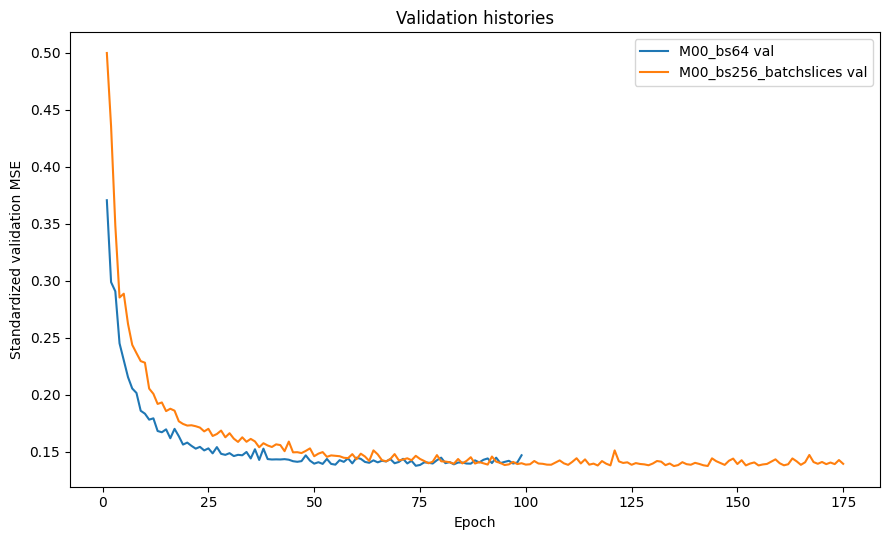

In [23]:
plt.figure(figsize=(9, 5.5))

for run_id, history in history_frames.items():
    plt.plot(
        history["epoch"],
        history["val_loss"],
        label=f"{run_id} val",
    )

plt.xlabel("Epoch")
plt.ylabel("Standardized validation MSE")
plt.title("Validation histories")
plt.legend()
plt.tight_layout()
plt.show()


### Important caveat about epoch comparisons

An epoch is not equivalent across batch sizes:

- bs64 performs roughly four times as many optimizer updates per epoch as bs256;
- compare both **epochs** and approximate optimizer steps;
- wall-clock time should be read from the checkpoint metadata or training logs.


In [24]:
TRAIN_SIZE = 400_000
BATCH_SIZE_BY_RUN = {
    "M00_bs64": 64,
    "M00_bs256_batchslices": 256,
}

if not history_summary_df.empty:
    history_summary_df["updates_per_epoch_approx"] = history_summary_df["run_id"].map(
        lambda run_id: TRAIN_SIZE // BATCH_SIZE_BY_RUN[run_id]
    )
    history_summary_df["optimizer_steps_at_best_approx"] = (
        history_summary_df["best_epoch"]
        * history_summary_df["updates_per_epoch_approx"]
    )

history_summary_df


,run_id,best_epoch,stop_epoch,best_val_loss,train_loss_at_best,generalization_gap_at_best,updates_per_epoch_approx,optimizer_steps_at_best_approx
0,M00_bs64,74,99,0.137901,0.140472,-0.002571,6250,462500
1,M00_bs256_batchslices,135,175,0.137655,0.137216,0.000440,1562,210870


## 9. Save comparison tables

In [26]:
metrics_df.to_csv(OUTPUT_DIR / "metrics_all_splits.csv", index=False)
quantiles_df.to_csv(OUTPUT_DIR / "absolute_error_quantiles.csv", index=False)
slopes_df.to_csv(OUTPUT_DIR / "slope_diagnostics.csv", index=False)
binned_df.to_csv(OUTPUT_DIR / "binned_true_diagnostics_test.csv", index=False)
test_delta_df.to_csv(OUTPUT_DIR / "test_deltas_bs256_vs_bs64.csv", index=False)
global_stability_df.to_csv(OUTPUT_DIR / "global_mse_stability.csv")
history_summary_df.to_csv(OUTPUT_DIR / "training_history_summary.csv", index=False)

print("Saved comparison tables to:", OUTPUT_DIR)


Saved comparison tables to: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/notebooks/outputs/comparison_500k_bs64_vs_bs256


## 10. Decision checklist

Treat bs256 as the new operational baseline if:

1. the test global standardized MSE is comparable to or lower than bs64;
2. no individual label degrades materially;
3. the slopes and predicted ranges are not more contracted;
4. the result is stable across val, cal and test;
5. training time is substantially reduced.

Do not choose the model using calibration-set performance. The calibration split is needed later to construct conformal intervals.
